STEP 1: Import Required Libraries

In [1]:
import cv2                          # OpenCV for image operations
import numpy as np                 # For arrays and math
import matplotlib.pyplot as plt    # For displaying images
from sklearn.mixture import GaussianMixture # For EM thresholding
import urllib.request
import ssl

STEP 2: Download Image

In [2]:
image_url = "https://drive.google.com/uc?export=download&id=1B0aNZy4zDQ1JqGlbN3YEllOTF9yApA7B"
context = ssl._create_unverified_context()
resp = urllib.request.urlopen(image_url, context=context)
image_np = np.asarray(bytearray(resp.read()), dtype="uint8")

# Decode as grayscale
gray = cv2.imdecode(image_np, cv2.IMREAD_GRAYSCALE)

if gray is None:
    raise Exception("Image could not be loaded. Check the URL or file format.")
else:
    print("✅ Image loaded successfully")

✅ Image loaded successfully


STEP 3: Random Thresholding

    Random thresholding assigns threshold values randomly to each pixel

    This is not practically useful but included here for experimentation

In [3]:
# Generate random thresholds for each pixel
random_thresholds = np.random.randint(0, 256, size=gray.shape, dtype=np.uint8)

# Apply pixel-wise threshold
binary_random = np.where(gray > random_thresholds, 255, 0).astype(np.uint8)

STEP 4: Global Thresholding

    Formula: dst(x,y) = 255 if src(x,y) > T else 0
    T is a manually chosen threshold (e.g., 127)

In [4]:
global_thresh = 127
_, binary_global = cv2.threshold(gray, global_thresh, 255, cv2.THRESH_BINARY)

STEP 5: Otsu's Thresholding

    Otsu's method finds the optimal T by minimizing intra-class variance
    It assumes a bimodal histogram (foreground + background)

In [5]:
_, binary_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

STEP 6: Adaptive Thresholding

    Computes different threshold T(x, y) for each pixel based on neighborhood
    Formula: dst(x,y) = 255 if src(x,y) > T(x,y) else 0

In [6]:
adaptive_mean = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                      cv2.THRESH_BINARY, 11, 2)

adaptive_gaussian = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                          cv2.THRESH_BINARY, 11, 2)

STEP 7: Expectation Maximization Thresholding (GMM)

    Model the pixel intensity distribution as 2 Gaussians (foreground + background)
    Use Expectation Maximization (EM) via Gaussian Mixture Model (GMM)
    Threshold is set to the midpoint between the two Gaussian means

In [7]:
pixels = gray.reshape(-1, 1)  # Flatten for GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(pixels)

means = np.sort(gmm.means_.flatten())  # Sort means low → high
threshold_em = int(np.mean(means))     # Midpoint threshold between the two clusters

# Apply threshold
_, binary_em = cv2.threshold(gray, threshold_em, 255, cv2.THRESH_BINARY)

print(f"📌 EM Threshold Value = {threshold_em}")
print(f"📌 Otsu Threshold Value = {int(_)}")

📌 EM Threshold Value = 188
📌 Otsu Threshold Value = 188


STEP 8: Plot All Thresholded Results

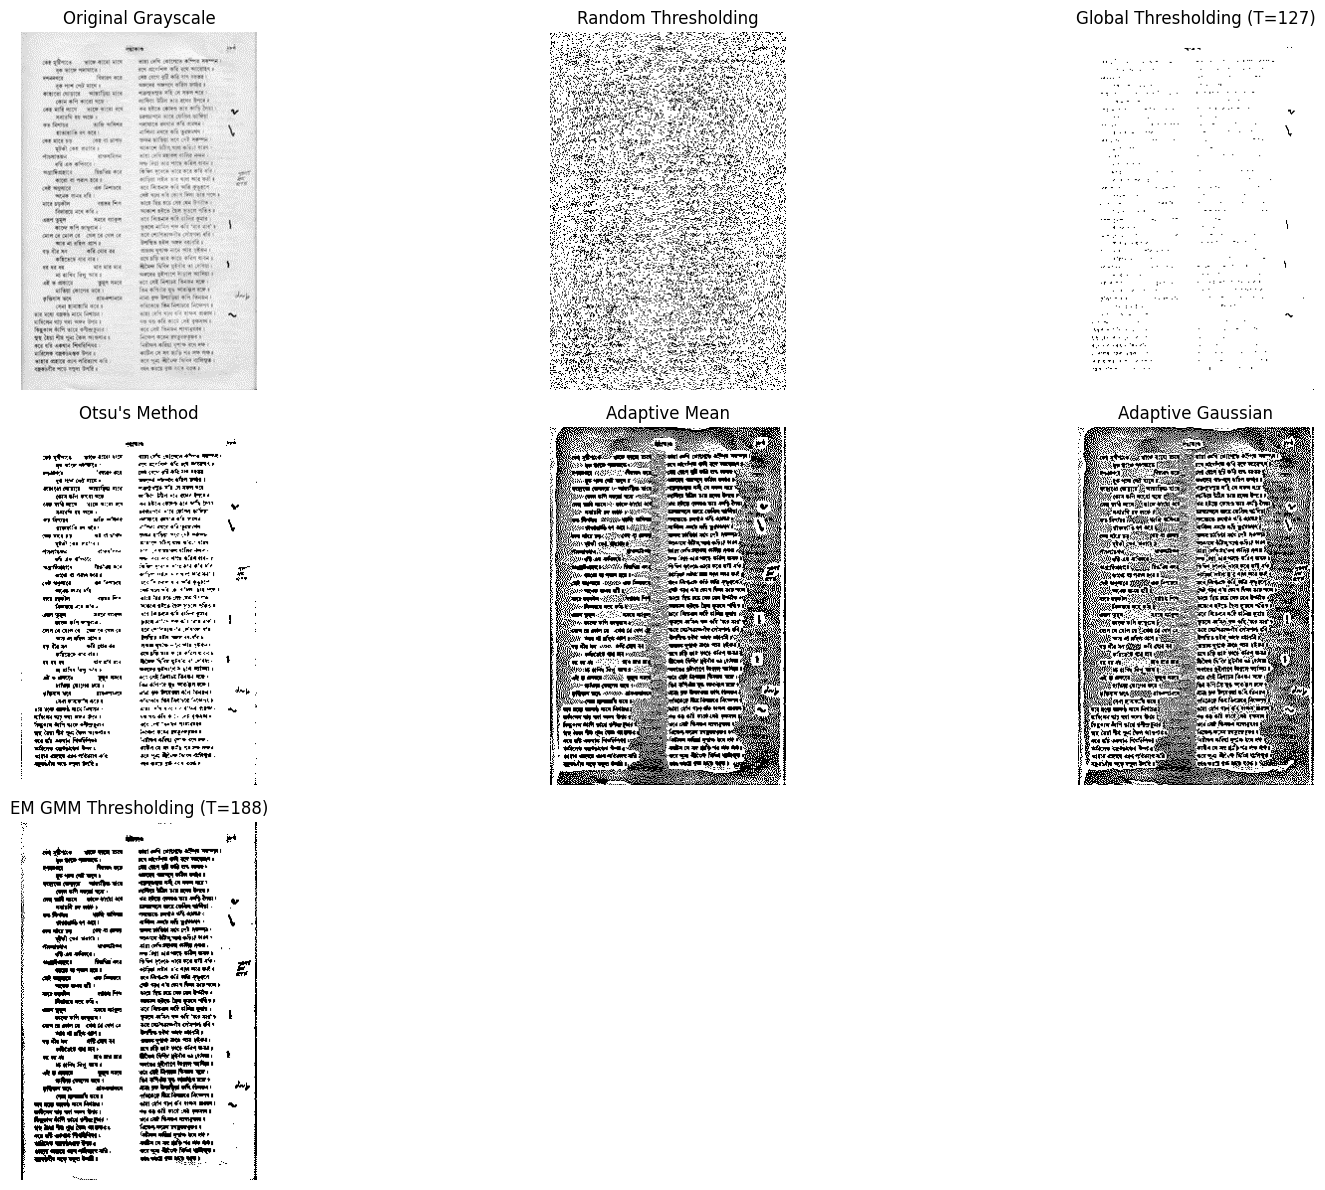

In [8]:
titles = ["Original Grayscale",
          "Random Thresholding",
          f"Global Thresholding (T={global_thresh})",
          f"Otsu's Method",
          "Adaptive Mean",
          "Adaptive Gaussian",
          f"EM GMM Thresholding (T={threshold_em})"]

images = [gray, binary_random, binary_global, binary_otsu, adaptive_mean, adaptive_gaussian, binary_em]

plt.figure(figsize=(16, 12))
for i in range(len(images)):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")
plt.tight_layout()
plt.show()
